In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [31]:
df = pd.read_csv("amazon_sales_dataset.csv")

In [32]:
features = [
    "price",
    "discount_percent",
    "quantity_sold",
    "rating",
    "review_count",
    "total_revenue"
]
X = df[features].dropna()

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [35]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

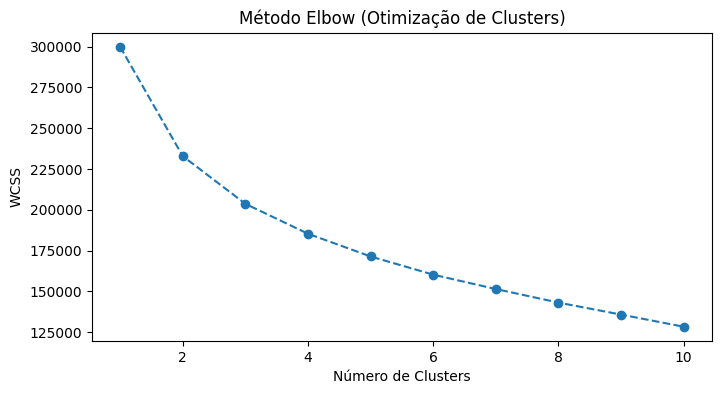

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método Elbow (Otimização de Clusters)')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

In [37]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [38]:
score = silhouette_score(X_scaled, df['cluster'])
print(f"\nSilhouette Score do Agrupamento: {score:.4f}")


Silhouette Score do Agrupamento: 0.1745


In [39]:
analysis = df.groupby('cluster')[features].mean()
print("\nPerfil Médio de cada Cluster:")
print(analysis)


Perfil Médio de cada Cluster:
              price  discount_percent  quantity_sold    rating  review_count  \
cluster                                                                        
0        327.687307         14.180110       1.642630  3.048014    250.363913   
1        364.355936         12.141073       4.209900  2.978188    249.861622   
2        104.631164         13.614168       3.130006  2.969333    248.085671   

         total_revenue  
cluster                 
0           460.104957  
1          1326.015531  
2           289.025241  


<Axes: xlabel='price', ylabel='total_revenue'>

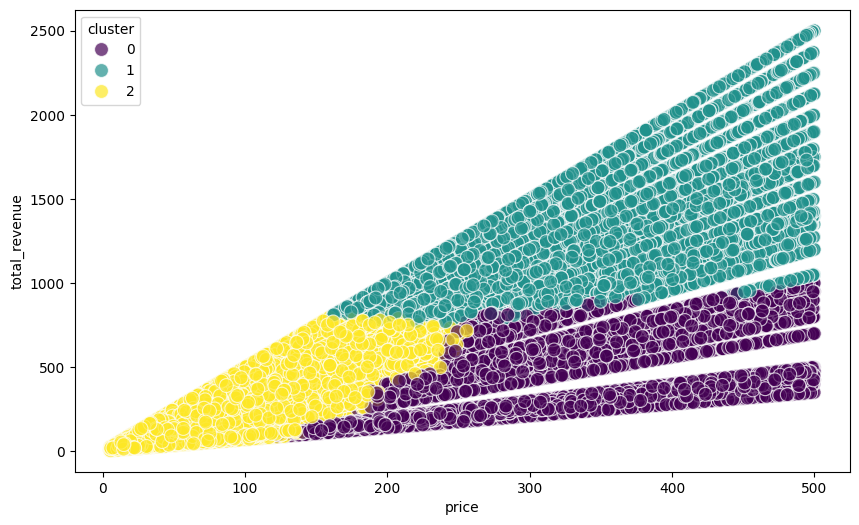

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="price",
    y="total_revenue",
    hue="cluster",
    palette="viridis",
    s=100,
    alpha=0.7
)

In [44]:
%matplotlib inline

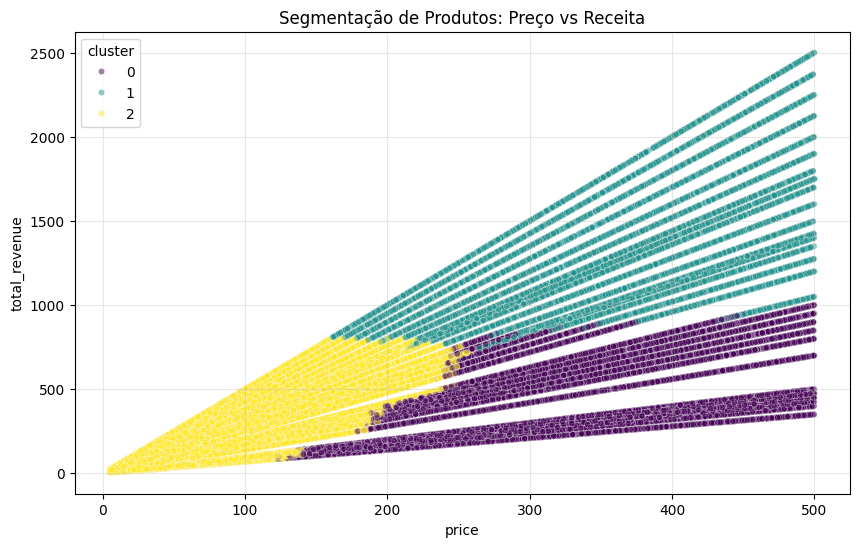

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="price",
    y="total_revenue",
    hue="cluster",
    palette="viridis",
    alpha=0.5,
    s=20
)
plt.title("Segmentação de Produtos: Preço vs Receita")
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
print("\n--- Insights Estratégicos ---")
for i in range(3):
    revenue_mean = analysis.loc[i, 'total_revenue']
    if revenue_mean == analysis['total_revenue'].max():
        print(f"Cluster {i}: Produtos Estrela (Alta Receita). Focar em manter stock e fidelização.")
    elif analysis.loc[i, 'price'] == analysis['price'].min():
        print(f"Cluster {i}: Produtos de Volume (Baixo preço, alta saída). Ideal para promoções de cross-selling.")
    else:
        print(f"Cluster {i}: Produtos de Nicho ou Performance Média. Analisar avaliações para melhoria de margem.")


--- Insights Estratégicos ---
Cluster 0: Produtos de Nicho ou Performance Média. Analisar avaliações para melhoria de margem.
Cluster 1: Produtos Estrela (Alta Receita). Focar em manter stock e fidelização.
Cluster 2: Produtos de Volume (Baixo preço, alta saída). Ideal para promoções de cross-selling.
